In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, ConfusionMatrixDisplay


In [29]:
df = pd.read_csv("online payment.csv")


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 10 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   step            1048575 non-null  int64  
 1   type            1048575 non-null  object 
 2   amount          1048575 non-null  float64
 3   nameOrig        1048575 non-null  object 
 4   oldbalanceOrg   1048551 non-null  float64
 5   newbalanceOrig  1048568 non-null  float64
 6   nameDest        1048575 non-null  object 
 7   oldbalanceDest  1048562 non-null  float64
 8   newbalanceDest  1048561 non-null  float64
 9   isFraud         1048573 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 80.0+ MB


In [4]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,NaN,0.0


In [5]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
count,1.048575e+06,1.048575e+06,1.048551e+06,1.048568e+06,1.048562e+06,1.048561e+06,1.048573e+06
mean,2.696617e+01,1.586670e+05,8.740246e+05,8.938090e+05,9.781600e+05,1.114206e+06,1.089099e-03
std,1.562325e+01,2.649409e+05,2.971757e+06,3.008255e+06,2.296786e+06,2.416568e+06,3.298354e-02
min,1.000000e+00,1.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.500000e+01,1.214907e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.000000e+01,7.634333e+04,1.600200e+04,0.000000e+00,1.263756e+05,2.182675e+05,0.000000e+00
75%,3.900000e+01,2.137619e+05,1.366503e+05,1.746018e+05,9.159137e+05,1.149873e+06,0.000000e+00
max,9.500000e+01,1.000000e+07,3.893942e+07,3.894623e+07,4.205466e+07,4.216916e+07,1.000000e+00


In [31]:
# Check initial missing values
print("\nMissing Values Before Handling:\n", df.isnull().sum())


Missing Values Before Handling:
 step               0
type               0
amount             0
nameOrig           0
oldbalanceOrg     24
newbalanceOrig     7
nameDest           0
oldbalanceDest    13
newbalanceDest    14
isFraud            2
dtype: int64


# Handle Missing Values

In [41]:
# Fill missing numerical values with median
df.fillna(df.select_dtypes(include=["number"]).median(), inplace=True)

# Fill missing categorical values with mode
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0]) 
# Clean numeric formatting (remove commas and convert)
numerical_cols = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
for col in numerical_cols:
    df[col] = df[col].astype(str).str.replace(',', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')


# Handle Outliers

In [45]:
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col], lower, upper)

In [11]:
# Check for Missing Values After Cleaning
print("Missing Values After Handling:\n", df.isnull().sum())

Missing Values After Handling:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64


# Data visulisation

C:\Users\vishnu\AppData\Local\Temp\ipykernel_8676\141198284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='isFraud', data=df, palette='pastel')


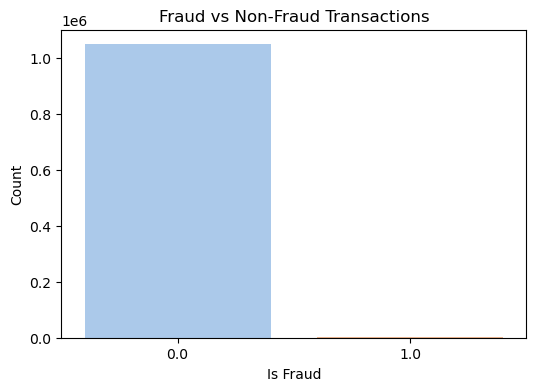

In [48]:
# 1. Target Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=df, palette='pastel')
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Is Fraud")
plt.ylabel("Count")
plt.show()

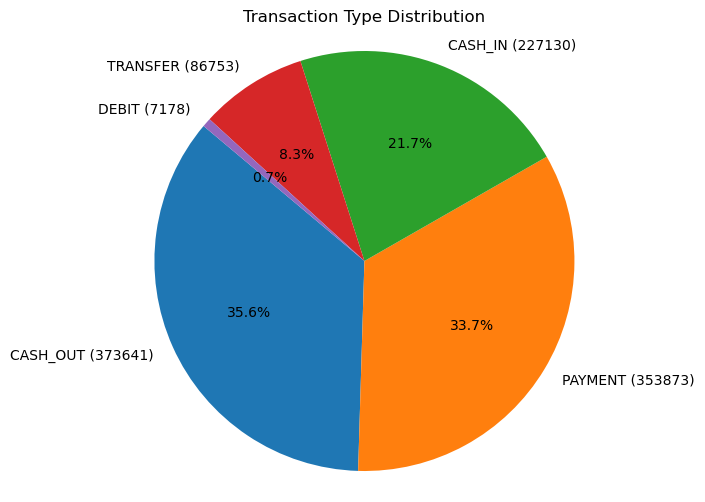

In [50]:
# 2. Type Distribution (Pie)
type_counts = df['type'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(type_counts, labels=[f'{i} ({j})' for i, j in zip(type_counts.index, type_counts)],
        autopct='%1.1f%%', startangle=140)
plt.title("Transaction Type Distribution")
plt.axis('equal')
plt.show()

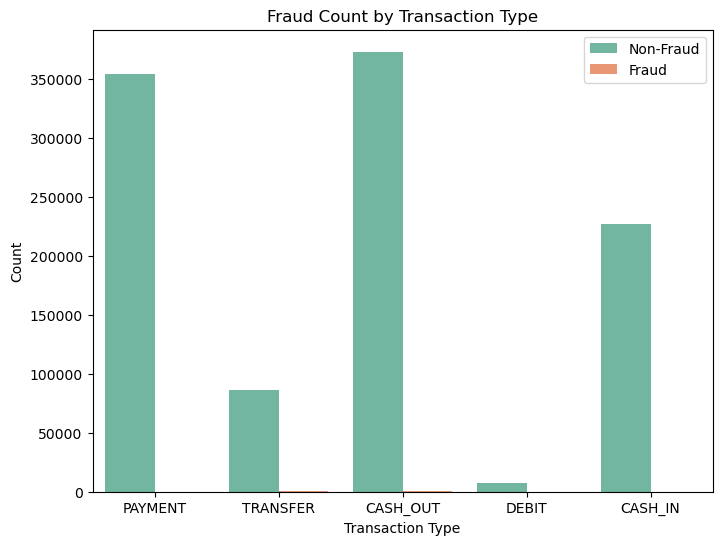

In [52]:
# 3. Fraud Count by Transaction Type
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='type', hue='isFraud', palette='Set2')
plt.title('Fraud Count by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.legend(['Non-Fraud', 'Fraud'])
plt.show()

C:\Users\vishnu\AppData\Local\Temp\ipykernel_8676\3174529776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='isFraud', y='amount', data=df, palette='coolwarm')


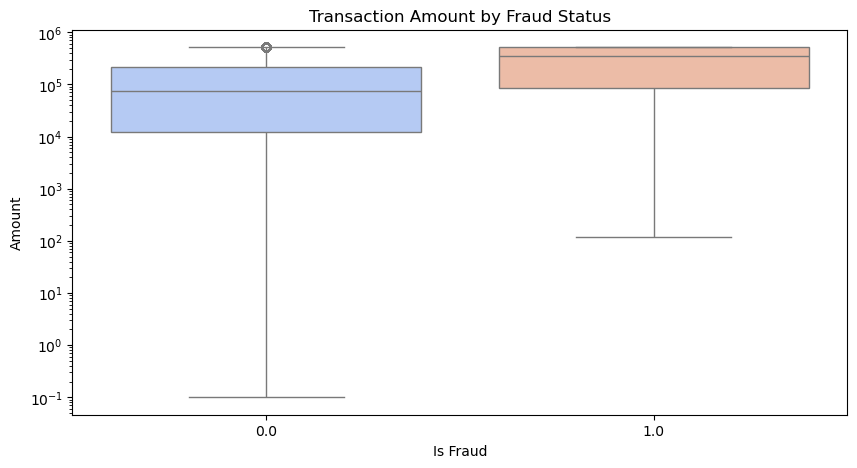

In [54]:
# 4. Amount distribution for fraud vs non-fraud
plt.figure(figsize=(10, 5))
sns.boxplot(x='isFraud', y='amount', data=df, palette='coolwarm')
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Amount')
plt.yscale('log')  # Log scale helps in visibility
plt.show()

<Axes: >

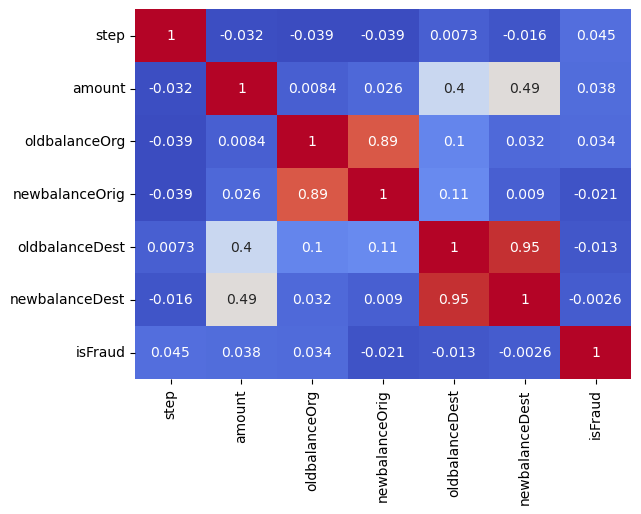

In [60]:
# 5. Correlation Heatmap
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm',cbar=None)

C:\Users\vishnu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


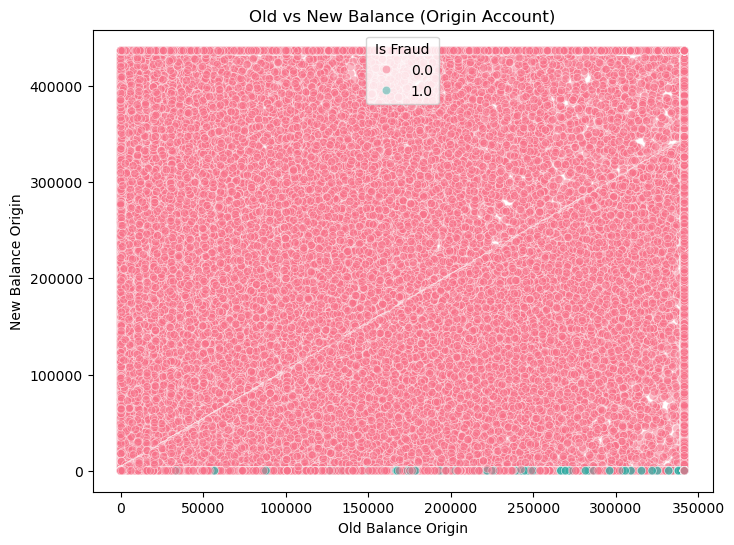

In [63]:
# 6. Scatterplot - Old vs New Balance Origin
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='oldbalanceOrg', y='newbalanceOrig', hue='isFraud', palette='husl', alpha=0.5)
plt.title("Old vs New Balance (Origin Account)")
plt.xlabel("Old Balance Origin")
plt.ylabel("New Balance Origin")
plt.legend(title='Is Fraud')
plt.show()

# Feature Engineering & Normalization

In [66]:
# One-hot encode 'type'
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [70]:
# Define Features & Target
X = df.drop(columns=['isFraud', 'nameOrig', 'nameDest'], errors='ignore')
y = df['isFraud']

# Encode other categorical variables
categorical_cols = X.select_dtypes(include=['object']).columns
print("Categorical Columns:", categorical_cols)



Categorical Columns: Index([], dtype='object')


In [76]:
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le



In [80]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [82]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [84]:
# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Evaluation
print("\nModel Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("ROC-AUC Score:", roc_auc_score(y_test, y_proba))


Model Accuracy: 0.9991226187921703

Classification Report:
               precision    recall  f1-score   support

         0.0       1.00      1.00      1.00    209487
         1.0       0.88      0.22      0.36       228

    accuracy                           1.00    209715
   macro avg       0.94      0.61      0.68    209715
weighted avg       1.00      1.00      1.00    209715

ROC-AUC Score: 0.9737605666440468


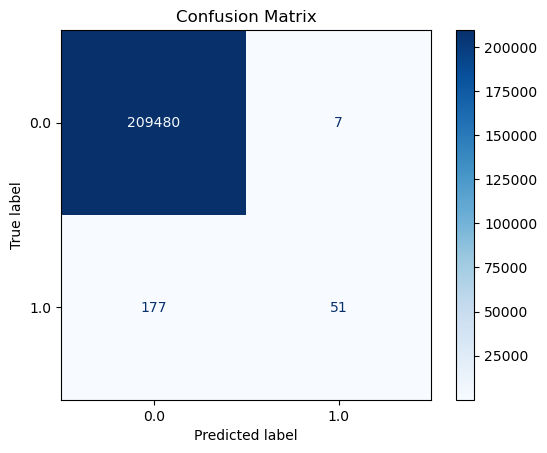

In [86]:
# Confusion Matrix
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# Feature Importance Plot

C:\Users\vishnu\AppData\Local\Temp\ipykernel_8676\273561244.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=important_features[:10], y=important_features.index[:10], palette='viridis')


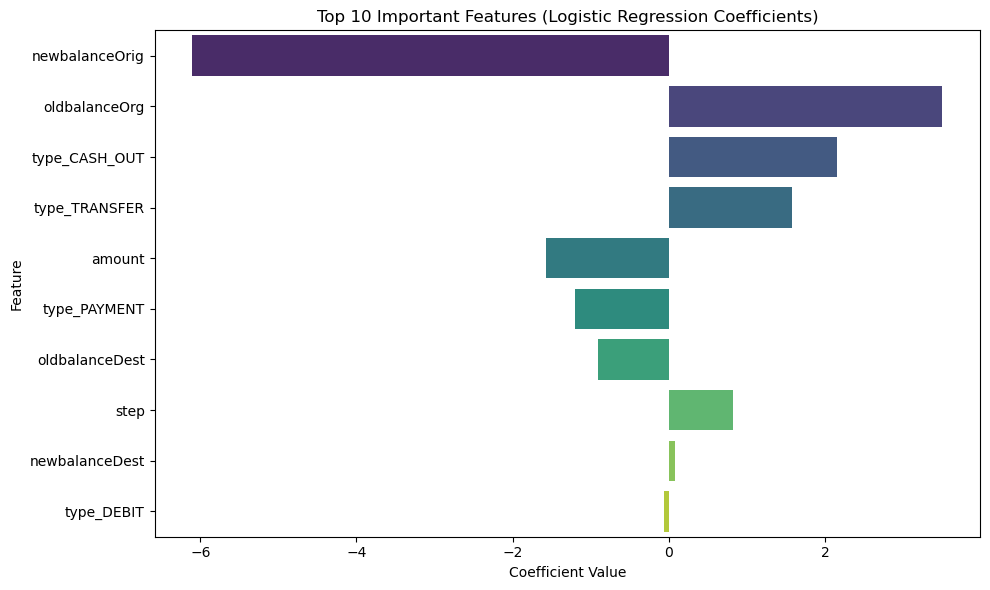

In [89]:
coefficients = pd.Series(model.coef_[0], index=X.columns)
important_features = coefficients.sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=important_features[:10], y=important_features.index[:10], palette='viridis')
plt.title("Top 10 Important Features (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()